In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append('../../')
from topo_metrics.collaborative_filtering.compute_metrics import compute_metrics
from topo_metrics.intrinsic_dim.intrinsic_dim import compute_intrinsic_dim_global, compute_intrinsic_dim_local

In [2]:
DATA_PATH = '/home/jovyan/klenitskiy/unsupervised_metric/embeds/rag/embeddings_2wiki/'
APPROACH = 'xrag'

LABEL_COLS = ['em', 'f1', 'substring_match', 'judge_correctness', 'judge_consistency']

In [3]:
labels = pd.read_json(os.path.join(DATA_PATH, APPROACH, 'results.json'))
print(labels.shape)
labels.head()

(2500, 13)


,id,query,target_answer,alternative_answers,generated_answer,num_chunks,embedding_shape,metadata,em,f1,substring_match,judge_correctness,judge_consistency
0,0,Who is the mother of the director of film Poli...,Małgorzata Braunek,[],Zka Warsołowska (daughter of the Polish-Russia...,1,"[1, 4096]","{'type': 'compositional', 'dataset': '2wikimul...",0,0.000000,0,0,1
1,1,"Which film came out first, Blind Shaft or The ...",The Mask Of Fu Manchu,[],The Mask Of Fu Manchu was released in 1932.,1,"[1, 4096]","{'type': 'comparison', 'dataset': '2wikimultih...",0,0.666667,1,1,1
2,2,"When did John V, Prince Of Anhalt-Zerbst's fat...",12 June 1516,[],1516.,1,"[1, 4096]","{'type': 'compositional', 'dataset': '2wikimul...",0,0.500000,0,0,1
3,3,What is the award that the director of film We...,Myanmar Motion Picture Academy Awards,[],The director of film Wearing Velvet Slippers U...,1,"[1, 4096]","{'type': 'compositional', 'dataset': '2wikimul...",0,0.333333,0,1,1
4,4,Where was the director of film Ronnie Rocket b...,"Missoula, Montana",[],"David Lynch was born in Missoula, Montana.",1,"[1, 4096]","{'type': 'compositional', 'dataset': '2wikimul...",0,0.444444,1,1,1


In [4]:
embs = np.load(os.path.join(DATA_PATH, APPROACH, 'embeddings.npy'))
embs.shape

(2500, 4096)

In [5]:
# old_metrics = compute_metrics(embs, selected_metrics=None, 
#                               n_samples=1, sample_fraction=1/10, verbose=False)

In [6]:
dim_global = compute_intrinsic_dim_global(embs, verbose=True)

MLE
Dimension: 39.66, time taken: 0.431 seconds
lPCA
Dimension: 35.00, time taken: 6.626 seconds
MOM
Dimension: 36.99, time taken: 0.419 seconds


In [7]:
dim_local, pointwise_dims = compute_intrinsic_dim_local(
    embs, n_neighbors=30, n_jobs=8, return_pointwise_dims=True, verbose=True)
# dim_local, pointwise_dims = compute_intrinsic_dim_local(
#     embs[:, 2, :], n_neighbors=30, n_jobs=8, return_pointwise_dims=True, verbose=True)

MLE
Dimension: 38.98, time taken: 0.427 seconds
TLE
Dimension: 33.39, time taken: 5.524 seconds
MOM
Dimension: 40.70, time taken: 0.410 seconds


In [8]:
result = labels[LABEL_COLS]
result['dim_MLE'] = pointwise_dims['MLE']
result['dim_TLE'] = pointwise_dims['TLE']
result['dim_MOM'] = pointwise_dims['MOM']
print(result.shape)
result = result[result['judge_correctness'] != -1]
print(result.shape)
result.head()

(2500, 8)
(2499, 8)


,em,f1,substring_match,judge_correctness,judge_consistency,dim_MLE,dim_TLE,dim_MOM
0,0,0.000000,0,0,1,18.750977,19.741388,21.616504
1,0,0.666667,1,1,1,60.746656,51.861361,62.923915
2,0,0.500000,0,0,1,14.166968,14.163379,15.337789
3,0,0.333333,0,1,1,35.697998,33.735052,39.200755
4,0,0.444444,1,1,1,43.208155,39.049850,46.462580


In [9]:
result.describe()

,em,f1,substring_match,judge_correctness,judge_consistency,dim_MLE,dim_TLE,dim_MOM
count,2499.000000,2499.000000,2499.000000,2499.000000,2499.000000,2499.000000,2499.000000,2499.000000
mean,0.100040,0.261006,0.427771,0.420168,0.994398,38.989017,33.395150,40.707825
std,0.300113,0.328654,0.494855,0.493685,0.079836,16.368106,12.445809,16.348954
min,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,7.140916,6.900799
25%,0.000000,0.000000,0.000000,0.000000,1.000000,27.392404,24.023841,28.739777
50%,0.000000,0.142857,0.000000,0.000000,1.000000,38.958879,33.098295,40.289811
75%,0.000000,0.400000,1.000000,1.000000,1.000000,49.271766,41.231046,50.959612
max,1.000000,1.000000,1.000000,1.000000,1.000000,111.190518,92.396634,115.083736


In [10]:
DIM_ESTIMATORS = ['dim_MLE', 'dim_TLE', 'dim_MOM']
corrs = []

for dim in DIM_ESTIMATORS:
    corrs.append(result[LABEL_COLS].corrwith(result[dim]))
corrs = pd.DataFrame(corrs, index=DIM_ESTIMATORS).T
corrs

,dim_MLE,dim_TLE,dim_MOM
em,0.027614,0.026801,0.025769
f1,0.037222,0.035215,0.033146
substring_match,0.214399,0.227408,0.216299
judge_correctness,0.138305,0.143450,0.139544
judge_consistency,0.038574,0.039647,0.037344


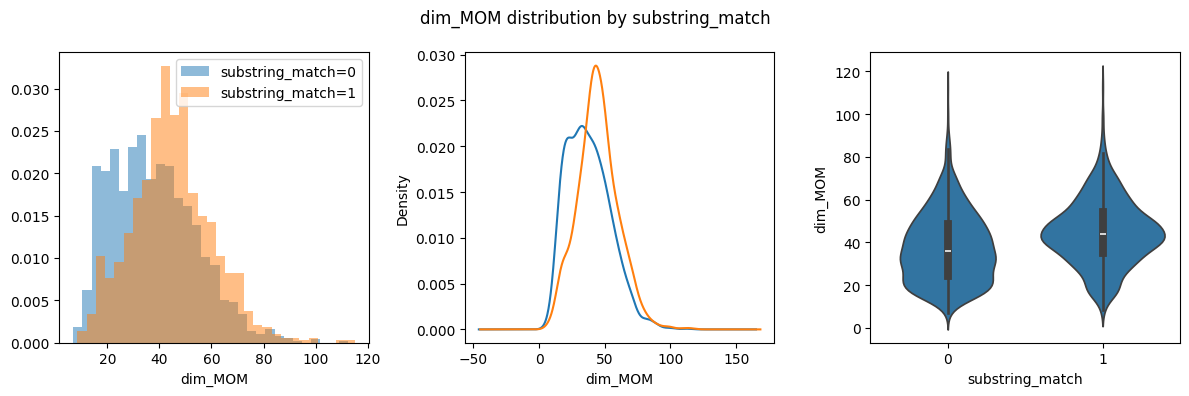

In [11]:
DIM_ESTIMATOR = 'dim_MOM'
LABEL = 'substring_match'

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle(f'{DIM_ESTIMATOR} distribution by {LABEL}')

for label, group in result.groupby(LABEL):
    axes[0].hist(group[DIM_ESTIMATOR], bins=30, alpha=0.5, density=True, label=f'{LABEL}={label}')
    group[DIM_ESTIMATOR].plot.kde(ax=axes[1])
axes[0].set_xlabel(DIM_ESTIMATOR)
axes[0].legend()
axes[1].set_xlabel(DIM_ESTIMATOR)

sns.violinplot(data=result, x=LABEL, y=DIM_ESTIMATOR,
               inner='box', ax=axes[2])
axes[2].set_xlabel(LABEL)

plt.tight_layout()
plt.show()

In [12]:
# plt.figure(figsize=(10, 6))
# plt.scatter(result[DIM_ESTIMATOR], result['f1'], alpha=0.5)
# plt.show()

